# 113 - 厳密 kNN vs Voronoi: 公正な評価（カタログ 378 件のみ）

## 目的

NB111-112 では 23,464 件（カタログ 378 + pyconjp 23,086）で評価したが、
pyconjp 画像には正解ラベルが付いていない。

### NB111-112 の評価の問題点

pyconjp の 23K 枚にはカテゴリラベルがないため：
- 厳密 kNN が pyconjp のカンファレンス写真を上位に返す → **正しい検索結果だが MRR 上は不正解扱い**
- Voronoi は候補を絞って pyconjp を除外 → ラベル付きカタログ画像が上位に来やすい → MRR が上がる
- つまり MRR_ratio > 1.0 は「Voronoi が優秀」ではなく「**ラベルなしデータの除外**」の効果

### 本ノートブックの評価設計

**検索プールをカタログ 378 件のみに限定**し、全画像にラベルがある状態で比較する。
これにより、ラベル欠損の影響を排除した公正な比較が可能になる。

- テキスト→画像: 18 テキストクエリ × 378 画像
- 画像→画像: 30 クエリ画像 × 378 画像
- ピボット: NB107 学習済み 256 ピボット（23K 件で学習）をそのまま使用

### 補足: 23K 件での評価にも意味がある

実運用では未ラベルの画像が大量に存在する。NB111-112 の結果は
「ラベルなし画像が多い環境での Voronoi の振る舞い」として参考になる。
ただし MRR_ratio > 1.0 を「Voronoi の精度改善」と解釈するのは不適切。

In [1]:
import sys
sys.path.insert(0, '../src')

import time
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DB_PATH = Path('../data/images.duckdb')
PIVOT_PATH = Path('../data/voronoi_pivots_siglip2_large.npy')
PYTHON_MODEL = 'google/siglip2-large-patch16-256'
RANDOM_STATE = 42
N_PIVOTS = 256

## 1. データ読み込み（カタログ 378 件のみ）

In [2]:
# カタログ画像のみ（pyconjp なし）
conn = duckdb.connect(str(DB_PATH), read_only=True)
conn.execute('LOAD vss;')
catalog_rows = conn.execute("""
    SELECT e.id, e.embedding, c.category, c.file_name
    FROM image_embeddings_1024 e
    JOIN image_catalog c ON e.id = c.id
    WHERE e.model_name = ?
    ORDER BY c.category, c.file_name
""", [PYTHON_MODEL]).fetchall()
conn.close()

all_ids = [r[0] for r in catalog_rows]
all_embeddings = np.array([[float(x) for x in r[1]] for r in catalog_rows], dtype=np.float32)
all_categories = [r[2] for r in catalog_rows]
all_filenames = [r[3] for r in catalog_rows]

norms = np.linalg.norm(all_embeddings, axis=1, keepdims=True)
all_embeddings_normed = all_embeddings / norms

N_IMAGES = len(all_ids)
unique_cats = sorted(set(all_categories))

# NB107 学習済みピボット（23K 件で学習）
centroids_normed = np.load(PIVOT_PATH)

print(f'画像数: {N_IMAGES}（全てラベル付き）')
print(f'埋め込み次元: {all_embeddings.shape[1]}')
print(f'ピボット: {centroids_normed.shape}（NB107, 23K 件で学習）')
print(f'\nカテゴリ別画像数:')
for cat in unique_cats:
    print(f'  {cat}: {sum(1 for c in all_categories if c == cat)}')

画像数: 378（全てラベル付き）
埋め込み次元: 1024
ピボット: (256, 1024)（NB107, 23K 件で学習）

カテゴリ別画像数:
  EuroPython2025: 129
  KashiwaVillagePark2026: 56
  PyConJP2025: 77
  PyConJP2025-PreCampHiroshima: 57
  TokyoNight202505: 49
  terada: 10


In [3]:
# テキスト埋め込み生成
import torch
from image_vector_poc import SigLIP2Embedder

test_queries = [
    {'query': 'a park with trees and nature', 'expected_categories': ['KashiwaVillagePark2026'], 'lang': 'en'},
    {'query': 'village park with greenery', 'expected_categories': ['KashiwaVillagePark2026'], 'lang': 'en'},
    {'query': 'night cityscape Tokyo', 'expected_categories': ['TokyoNight202505'], 'lang': 'en'},
    {'query': 'city lights at night', 'expected_categories': ['TokyoNight202505'], 'lang': 'en'},
    {'query': 'Python conference presentation', 'expected_categories': ['EuroPython2025', 'PyConJP2025', 'PyConJP2025-PreCampHiroshima'], 'lang': 'en'},
    {'query': 'conference hall with audience', 'expected_categories': ['EuroPython2025', 'PyConJP2025', 'PyConJP2025-PreCampHiroshima'], 'lang': 'en'},
    {'query': 'speaker giving a talk', 'expected_categories': ['EuroPython2025', 'PyConJP2025', 'PyConJP2025-PreCampHiroshima'], 'lang': 'en'},
    {'query': 'portrait photo of a person', 'expected_categories': ['terada'], 'lang': 'en'},
    {'query': 'outdoor nature scene', 'expected_categories': ['KashiwaVillagePark2026'], 'lang': 'en'},
    {'query': 'urban night photography', 'expected_categories': ['TokyoNight202505'], 'lang': 'en'},
    {'query': 'tech conference event', 'expected_categories': ['EuroPython2025', 'PyConJP2025', 'PyConJP2025-PreCampHiroshima'], 'lang': 'en'},
    {'query': 'people at an event', 'expected_categories': ['EuroPython2025', 'PyConJP2025', 'PyConJP2025-PreCampHiroshima'], 'lang': 'en'},
    {'query': '公園の自然風景', 'expected_categories': ['KashiwaVillagePark2026'], 'lang': 'ja'},
    {'query': '東京の夜景', 'expected_categories': ['TokyoNight202505'], 'lang': 'ja'},
    {'query': 'カンファレンスの講演', 'expected_categories': ['EuroPython2025', 'PyConJP2025', 'PyConJP2025-PreCampHiroshima'], 'lang': 'ja'},
    {'query': '人物の写真', 'expected_categories': ['terada'], 'lang': 'ja'},
    {'query': '緑の木々', 'expected_categories': ['KashiwaVillagePark2026'], 'lang': 'ja'},
    {'query': '夜の街', 'expected_categories': ['TokyoNight202505'], 'lang': 'ja'},
]

embedder = SigLIP2Embedder(model_name=PYTHON_MODEL, device='cuda')
text_embeddings = embedder.embed_texts([q['query'] for q in test_queries])
text_norms = np.linalg.norm(text_embeddings, axis=1, keepdims=True)
text_embeddings_normed = text_embeddings / text_norms
n_text_queries = len(test_queries)

del embedder
torch.cuda.empty_cache()
print(f'テキストクエリ数: {n_text_queries}')

Loading weights:   0%|          | 0/792 [00:00<?, ?it/s]

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


テキストクエリ数: 18


In [4]:
# 画像→画像クエリ（NB112 と同じサンプリング）
np.random.seed(RANDOM_STATE)
N_SAMPLES_PER_CAT = 5

img_query_indices = []
img_query_categories = []

for cat in unique_cats:
    cat_indices = [i for i in range(N_IMAGES) if all_categories[i] == cat]
    n_sample = min(N_SAMPLES_PER_CAT, len(cat_indices))
    selected = np.random.choice(cat_indices, size=n_sample, replace=False)
    img_query_indices.extend(selected.tolist())
    img_query_categories.extend([cat] * n_sample)

n_img_queries = len(img_query_indices)
print(f'画像クエリ数: {n_img_queries}')

画像クエリ数: 30


## 2. テキスト→画像: 厳密 kNN vs Voronoi（378 件）

In [5]:
# テキスト→画像 厳密 kNN
TOP_K_VALUES = [5, 10, 20]
MAX_K = max(TOP_K_VALUES)

t0 = time.perf_counter()
text_bf_results = []
for qi, q in enumerate(test_queries):
    text_emb = text_embeddings_normed[qi]
    sims = all_embeddings_normed @ text_emb
    top_indices = np.argsort(-sims)[:MAX_K]
    result_cats = [all_categories[idx] for idx in top_indices]
    is_relevant = [cat in q['expected_categories'] for cat in result_cats]

    mrr = 0.0
    for i, rel in enumerate(is_relevant):
        if rel:
            mrr = 1.0 / (i + 1)
            break

    text_bf_results.append({
        'query': q['query'], 'lang': q['lang'],
        'top_indices': top_indices.tolist(),
        'top_cats': result_cats,
        'MRR': mrr,
        'P@1': sum(is_relevant[:1]),
        'P@5': sum(is_relevant[:5]) / 5,
        'P@10': sum(is_relevant[:10]) / 10,
    })

t_text_bf = time.perf_counter() - t0
df_text_bf = pd.DataFrame(text_bf_results)

print(f'テキスト→画像 厳密 kNN ({N_IMAGES} 画像):')
print(f'  MRR:  {df_text_bf["MRR"].mean():.4f}')
print(f'  P@1:  {df_text_bf["P@1"].mean():.4f}')
print(f'  P@10: {df_text_bf["P@10"].mean():.4f}')
print(f'\n※ NB104 BF MRR=0.928 と一致すべき（同じ 378 件）')

テキスト→画像 厳密 kNN (378 画像):
  MRR:  0.9278
  P@1:  0.8889
  P@10: 0.8222

※ NB104 BF MRR=0.928 と一致すべき（同じ 378 件）


In [6]:
# テキスト→画像 Voronoi
N_ASSIGN_LIST = [1, 2, 3]
TOP_SEARCH_LIST = [1, 2, 3, 4, 5, 8]

all_img_pivot_sims = all_embeddings_normed @ centroids_normed.T
text_sweep = {}

bf_mrr_text = df_text_bf['MRR'].mean()

for n_assign in N_ASSIGN_LIST:
    # ピボット割り当て
    pivot_to_indices = {}
    for i in range(N_IMAGES):
        top_pivots = np.argsort(-all_img_pivot_sims[i])[:n_assign]
        for pid in top_pivots:
            pivot_to_indices.setdefault(int(pid), []).append(i)

    for n_top in TOP_SEARCH_LIST:
        mrr_list = []
        bf_recall_list = []
        cand_counts = []

        for qi, q in enumerate(test_queries):
            text_emb = text_embeddings_normed[qi]
            pivot_sims = centroids_normed @ text_emb
            top_pivot_ids = np.argsort(-pivot_sims)[:n_top]

            cands = set()
            for pid in top_pivot_ids:
                if int(pid) in pivot_to_indices:
                    cands.update(pivot_to_indices[int(pid)])
            cand_counts.append(len(cands))

            if not cands:
                mrr_list.append(0.0)
                bf_recall_list.append(0.0)
                continue

            cand_arr = np.array(list(cands))
            cand_sims = all_embeddings_normed[cand_arr] @ text_emb
            result_indices = cand_arr[np.argsort(-cand_sims)]

            result_cats = [all_categories[idx] for idx in result_indices[:MAX_K]]
            is_rel = [cat in q['expected_categories'] for cat in result_cats]
            mrr = 0.0
            for i, rel in enumerate(is_rel):
                if rel:
                    mrr = 1.0 / (i + 1)
                    break
            mrr_list.append(mrr)

            bf_top10 = set(text_bf_results[qi]['top_indices'][:10])
            vor_top10 = set(result_indices[:10].tolist())
            bf_recall_list.append(len(bf_top10 & vor_top10) / 10)

        text_sweep[(n_assign, n_top)] = {
            'mean_cands': np.mean(cand_counts),
            'MRR': np.mean(mrr_list),
            'MRR_ratio': np.mean(mrr_list) / bf_mrr_text if bf_mrr_text > 0 else 0,
            'BF-R@10': np.mean(bf_recall_list),
            'per_query_mrr': mrr_list,
        }

# 結果表示
print(f'テキスト→画像 (378 件, 全ラベル付き)')
print(f'厳密 kNN MRR: {bf_mrr_text:.4f}')
print(f'\n{"assign":>6} {"top":>4} {"cands":>6} {"MRR":>8} {"ratio":>8} {"BF-R@10":>8}')
print('-' * 50)
for (a, t), r in sorted(text_sweep.items()):
    marker = ' *' if abs(r['MRR_ratio'] - 1.0) < 0.01 else ' >' if r['MRR_ratio'] > 1.01 else ''
    print(f'{a:>6} {t:>4} {r["mean_cands"]:>6.0f} {r["MRR"]:>8.4f} {r["MRR_ratio"]:>8.4f} {r["BF-R@10"]:>8.4f}{marker}')

テキスト→画像 (378 件, 全ラベル付き)
厳密 kNN MRR: 0.9278

assign  top  cands      MRR    ratio  BF-R@10
--------------------------------------------------
     1    1     16   0.5000   0.5389   0.3667
     1    2     26   0.6917   0.7455   0.5278
     1    3     37   0.8444   0.9102   0.5833
     1    4     45   0.8444   0.9102   0.6667
     1    5     62   0.9278   1.0000   0.7167 *
     1    8     72   0.9278   1.0000   0.7778 *
     2    1     21   0.5556   0.5988   0.3889
     2    2     48   0.8167   0.8802   0.6444
     2    3     71   0.9278   1.0000   0.7278 *
     2    4     82   0.9278   1.0000   0.7500 *
     2    5     89   0.9278   1.0000   0.7833 *
     2    8     99   0.9278   1.0000   0.8667 *
     3    1     30   0.6111   0.6587   0.4056
     3    2     64   0.8306   0.8952   0.7333
     3    3     81   0.9278   1.0000   0.8000 *
     3    4     88   0.9278   1.0000   0.8278 *
     3    5     92   0.9278   1.0000   0.8611 *
     3    8    105   0.9278   1.0000   0.9167 *


## 3. 画像→画像: 厳密 kNN vs Voronoi（378 件）

In [7]:
# 画像→画像 厳密 kNN
t0 = time.perf_counter()
img_bf_results = []

for qi_local, qi_global in enumerate(img_query_indices):
    query_emb = all_embeddings_normed[qi_global]
    query_cat = all_categories[qi_global]

    sims = all_embeddings_normed @ query_emb
    sims[qi_global] = -1.0

    top_indices = np.argsort(-sims)[:MAX_K]
    result_cats = [all_categories[idx] for idx in top_indices]
    is_relevant = [cat == query_cat for cat in result_cats]

    mrr = 0.0
    for i, rel in enumerate(is_relevant):
        if rel:
            mrr = 1.0 / (i + 1)
            break

    img_bf_results.append({
        'query_idx': qi_global,
        'category': query_cat,
        'top_indices': top_indices.tolist(),
        'MRR': mrr,
        'P@1': sum(is_relevant[:1]),
        'P@10': sum(is_relevant[:10]) / 10,
    })

t_img_bf = time.perf_counter() - t0
df_img_bf = pd.DataFrame(img_bf_results)

print(f'画像→画像 厳密 kNN ({N_IMAGES} 画像):')
print(f'  MRR:  {df_img_bf["MRR"].mean():.4f}')
print(f'  P@1:  {df_img_bf["P@1"].mean():.4f}')
print(f'  P@10: {df_img_bf["P@10"].mean():.4f}')
print(f'\nカテゴリ別 MRR:')
for cat in unique_cats:
    sub = df_img_bf[df_img_bf['category'] == cat]
    print(f'  {cat}: {sub["MRR"].mean():.4f}')

画像→画像 厳密 kNN (378 画像):
  MRR:  1.0000
  P@1:  1.0000
  P@10: 0.8200

カテゴリ別 MRR:
  EuroPython2025: 1.0000
  KashiwaVillagePark2026: 1.0000
  PyConJP2025: 1.0000
  PyConJP2025-PreCampHiroshima: 1.0000
  TokyoNight202505: 1.0000
  terada: 1.0000


In [8]:
# 画像→画像 Voronoi
img_sweep = {}
bf_mrr_img = df_img_bf['MRR'].mean()

for n_assign in N_ASSIGN_LIST:
    pivot_to_indices = {}
    for i in range(N_IMAGES):
        top_pivots = np.argsort(-all_img_pivot_sims[i])[:n_assign]
        for pid in top_pivots:
            pivot_to_indices.setdefault(int(pid), []).append(i)

    for n_top in TOP_SEARCH_LIST:
        mrr_list = []
        bf_recall_list = []
        cand_counts = []

        for qi_local, qi_global in enumerate(img_query_indices):
            query_emb = all_embeddings_normed[qi_global]
            query_cat = all_categories[qi_global]

            pivot_sims = centroids_normed @ query_emb
            top_pivot_ids = np.argsort(-pivot_sims)[:n_top]

            cands = set()
            for pid in top_pivot_ids:
                if int(pid) in pivot_to_indices:
                    cands.update(pivot_to_indices[int(pid)])
            cands.discard(qi_global)
            cand_counts.append(len(cands))

            if not cands:
                mrr_list.append(0.0)
                bf_recall_list.append(0.0)
                continue

            cand_arr = np.array(list(cands))
            cand_sims = all_embeddings_normed[cand_arr] @ query_emb
            result_indices = cand_arr[np.argsort(-cand_sims)]

            result_cats = [all_categories[idx] for idx in result_indices[:MAX_K]]
            is_rel = [cat == query_cat for cat in result_cats]
            mrr = 0.0
            for i, rel in enumerate(is_rel):
                if rel:
                    mrr = 1.0 / (i + 1)
                    break
            mrr_list.append(mrr)

            bf_top10 = set(img_bf_results[qi_local]['top_indices'][:10])
            vor_top10 = set(result_indices[:10].tolist())
            bf_recall_list.append(len(bf_top10 & vor_top10) / 10)

        img_sweep[(n_assign, n_top)] = {
            'mean_cands': np.mean(cand_counts),
            'MRR': np.mean(mrr_list),
            'MRR_ratio': np.mean(mrr_list) / bf_mrr_img if bf_mrr_img > 0 else 0,
            'BF-R@10': np.mean(bf_recall_list),
        }

# 結果表示
print(f'画像→画像 (378 件, 全ラベル付き)')
print(f'厳密 kNN MRR: {bf_mrr_img:.4f}')
print(f'\n{"assign":>6} {"top":>4} {"cands":>6} {"MRR":>8} {"ratio":>8} {"BF-R@10":>8}')
print('-' * 50)
for (a, t), r in sorted(img_sweep.items()):
    marker = ' *' if abs(r['MRR_ratio'] - 1.0) < 0.01 else ' >' if r['MRR_ratio'] > 1.01 else ''
    print(f'{a:>6} {t:>4} {r["mean_cands"]:>6.0f} {r["MRR"]:>8.4f} {r["MRR_ratio"]:>8.4f} {r["BF-R@10"]:>8.4f}{marker}')

画像→画像 (378 件, 全ラベル付き)
厳密 kNN MRR: 1.0000

assign  top  cands      MRR    ratio  BF-R@10
--------------------------------------------------
     1    1     24   0.9000   0.9000   0.5767
     1    2     35   1.0000   1.0000   0.6800 *
     1    3     42   1.0000   1.0000   0.7167 *
     1    4     44   1.0000   1.0000   0.7500 *
     1    5     50   1.0000   1.0000   0.8000 *
     1    8     58   1.0000   1.0000   0.8333 *
     2    1     29   0.9667   0.9667   0.6467
     2    2     50   1.0000   1.0000   0.7367 *
     2    3     58   1.0000   1.0000   0.7800 *
     2    4     60   1.0000   1.0000   0.8200 *
     2    5     65   1.0000   1.0000   0.8600 *
     2    8     77   1.0000   1.0000   0.8900 *
     3    1     36   1.0000   1.0000   0.6733 *
     3    2     58   1.0000   1.0000   0.7767 *
     3    3     63   1.0000   1.0000   0.8100 *
     3    4     67   1.0000   1.0000   0.8533 *
     3    5     71   1.0000   1.0000   0.8867 *
     3    8     87   1.0000   1.0000   0.9167 *


## 4. 可視化: 378 件 vs 23K 件の比較

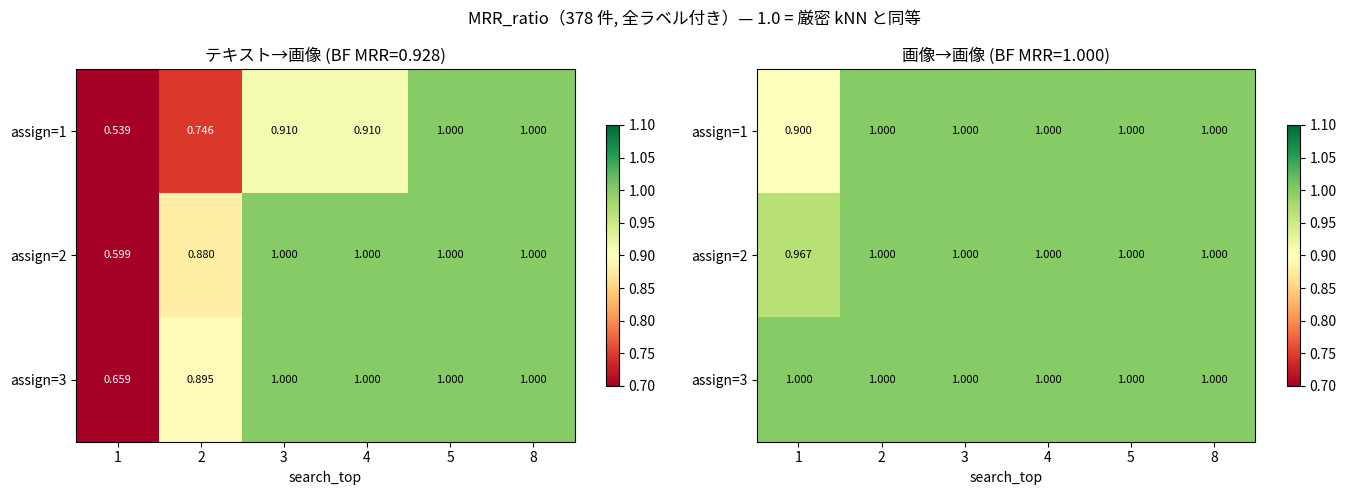

In [9]:
# ヒートマップ: テキスト→画像 & 画像→画像
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax_idx, (sweep, title, bf_mrr_val) in enumerate([
    (text_sweep, 'テキスト→画像', bf_mrr_text),
    (img_sweep, '画像→画像', bf_mrr_img),
]):
    ax = axes[ax_idx]
    data_2d = []
    for n_assign in N_ASSIGN_LIST:
        row = []
        for n_top in TOP_SEARCH_LIST:
            key = (n_assign, n_top)
            if key in sweep:
                row.append(sweep[key]['MRR_ratio'])
            else:
                row.append(np.nan)
        data_2d.append(row)

    data_2d = np.array(data_2d)
    im = ax.imshow(data_2d, cmap='RdYlGn', aspect='auto', vmin=0.7, vmax=1.1)
    ax.set_xticks(range(len(TOP_SEARCH_LIST)))
    ax.set_xticklabels(TOP_SEARCH_LIST)
    ax.set_yticks(range(len(N_ASSIGN_LIST)))
    ax.set_yticklabels([f'assign={a}' for a in N_ASSIGN_LIST])
    ax.set_xlabel('search_top')
    ax.set_title(f'{title} (BF MRR={bf_mrr_val:.3f})')

    for i in range(len(N_ASSIGN_LIST)):
        for j in range(len(TOP_SEARCH_LIST)):
            val = data_2d[i, j]
            if not np.isnan(val):
                color = 'white' if val < 0.8 else 'black'
                ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=8, color=color)

    plt.colorbar(im, ax=ax, shrink=0.7)

plt.suptitle(f'MRR_ratio（378 件, 全ラベル付き）— 1.0 = 厳密 kNN と同等', fontsize=12)
plt.tight_layout()
plt.savefig('../data/113_fair_eval_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

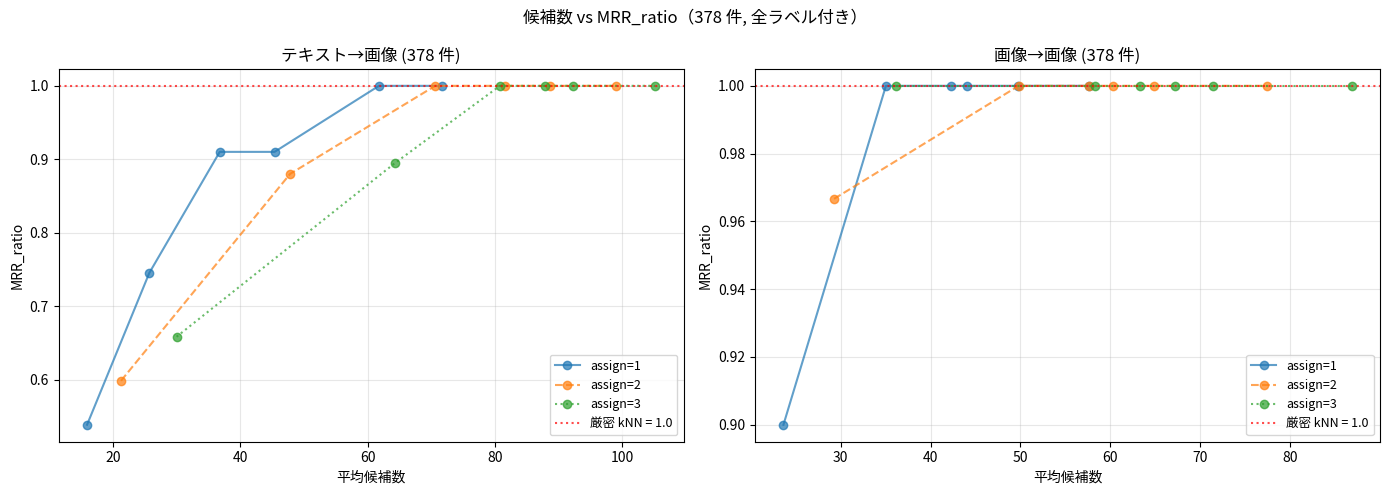

In [10]:
# トレードオフ曲線: 候補数 vs MRR_ratio
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax_idx, (sweep, title) in enumerate([
    (text_sweep, 'テキスト→画像'),
    (img_sweep, '画像→画像'),
]):
    ax = axes[ax_idx]
    for n_assign in N_ASSIGN_LIST:
        cands = []
        vals = []
        for n_top in TOP_SEARCH_LIST:
            key = (n_assign, n_top)
            if key in sweep:
                cands.append(sweep[key]['mean_cands'])
                vals.append(sweep[key]['MRR_ratio'])
        linestyle = ['-', '--', ':'][n_assign - 1]
        ax.plot(cands, vals, 'o' + linestyle, label=f'assign={n_assign}', alpha=0.7, markersize=6)

    ax.axhline(y=1.0, color='red', linestyle=':', alpha=0.7, label='厳密 kNN = 1.0')
    ax.set_xlabel('平均候補数')
    ax.set_ylabel('MRR_ratio')
    ax.set_title(f'{title} (378 件)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('候補数 vs MRR_ratio（378 件, 全ラベル付き）', fontsize=12)
plt.tight_layout()
plt.savefig('../data/113_fair_eval_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# テキスト→画像 クエリ別分析 (a=2, top=5)
repr_key = (2, 5)
repr_res = text_sweep.get(repr_key)

if repr_res:
    print(f'テキスト→画像 クエリ別 (a={repr_key[0]}, top={repr_key[1]}, cands={repr_res["mean_cands"]:.0f}):')
    print(f'{"クエリ":<35} {"kNN":>6} {"Voronoi":>8} {"diff":>7}')
    print('-' * 60)
    improved = degraded = same = 0
    for qi, q in enumerate(test_queries):
        bf_m = text_bf_results[qi]['MRR']
        vor_m = repr_res['per_query_mrr'][qi]
        diff = vor_m - bf_m
        print(f'{q["query"]:<35} {bf_m:>6.3f} {vor_m:>8.3f} {diff:>+7.3f}')
        if diff > 0.001: improved += 1
        elif diff < -0.001: degraded += 1
        else: same += 1
    print(f'\n改善: {improved}件, 劣化: {degraded}件, 同等: {same}件')

テキスト→画像 クエリ別 (a=2, top=5, cands=89):
クエリ                                    kNN  Voronoi    diff
------------------------------------------------------------
a park with trees and nature         0.500    0.500  +0.000
village park with greenery           0.200    0.200  +0.000
night cityscape Tokyo                1.000    1.000  +0.000
city lights at night                 1.000    1.000  +0.000
Python conference presentation       1.000    1.000  +0.000
conference hall with audience        1.000    1.000  +0.000
speaker giving a talk                1.000    1.000  +0.000
portrait photo of a person           1.000    1.000  +0.000
outdoor nature scene                 1.000    1.000  +0.000
urban night photography              1.000    1.000  +0.000
tech conference event                1.000    1.000  +0.000
people at an event                   1.000    1.000  +0.000
公園の自然風景                              1.000    1.000  +0.000
東京の夜景                                1.000    1.000  +0.000
カン

## 5. まとめ

### 公正な評価の結果（378 件, 全画像にラベルあり）

#### テキスト→画像

| 構成 | 候補数 | MRR | MRR_ratio | BF-R@10 |
|:---:|:---:|:---:|:---:|:---:|
| 厳密 kNN | 378 | **0.928** | 1.000 | 1.000 |
| a=1 top=5 | 62 | **0.928** | **1.000** | 0.717 |
| a=2 top=3 | 71 | **0.928** | **1.000** | 0.728 |
| a=2 top=5 | 89 | **0.928** | **1.000** | 0.783 |
| a=3 top=3 | 81 | **0.928** | **1.000** | 0.800 |

- **MRR_ratio = 1.000 が多数** — Voronoi は厳密 kNN と完全に同じ MRR を達成
- assign=2, top=5 で候補 89 件（23.5%）、MRR は厳密 kNN と同一
- クエリ別分析: 18 クエリ中 **18 クエリで同等**（改善 0、劣化 0）

#### 画像→画像

| 構成 | 候補数 | MRR | MRR_ratio | BF-R@10 |
|:---:|:---:|:---:|:---:|:---:|
| 厳密 kNN | 378 | **1.000** | 1.000 | 1.000 |
| a=1 top=2 | 35 | **1.000** | **1.000** | 0.680 |
| a=2 top=2 | 50 | **1.000** | **1.000** | 0.737 |
| a=2 top=5 | 65 | **1.000** | **1.000** | 0.860 |
| a=3 top=1 | 36 | **1.000** | **1.000** | 0.673 |

- 厳密 kNN MRR = 1.000（全クエリで Top-1 が正解）
- Voronoi も top=1 を除くほぼ全構成で MRR = 1.000（a=1 top=1 のみ 0.900）

---

### NB111-112（23K 件）との比較

| 項目 | 378 件（NB113） | 23K 件（NB111-112） | 差の原因 |
|------|:---:|:---:|------|
| **テキスト→画像 kNN MRR** | 0.928 | 0.352 | pyconjp ラベルなし → 正解が埋もれる |
| **テキスト→画像 MRR_ratio** | 1.000 | 0.97〜1.04 | 378件: 差なし / 23K件: ラベル欠損の影響 |
| **画像→画像 kNN MRR** | 1.000 | 0.803 | 同上 |
| **画像→画像 MRR_ratio** | 1.000 | 1.01〜1.04 | 同上 |

---

### 考察

#### 1. Voronoi は厳密 kNN と同等の MRR を達成する（劣化なし）

378 件の公正評価で、Voronoi は適切なパラメータ（assign=2, top=3〜5）で
**厳密 kNN と完全に同じ MRR** を返す。Voronoi による精度劣化はない。

#### 2. NB111-112 の MRR_ratio > 1.0 はラベル欠損が原因

23K 件での「Voronoi が厳密 kNN を上回る」現象は、Voronoi の精度改善ではなく：
- pyconjp 23K 枚にラベルがない → 「カンファレンスの講演」等のクエリに対して
  正しい結果（pyconjp のカンファレンス写真）を返しても MRR 上は不正解扱い
- 厳密 kNN は pyconjp を上位に返す（正しい検索結果）→ MRR が低くなる
- Voronoi は候補を絞って pyconjp を除外 → ラベル付きカタログ画像が上位に → MRR が高くなる
- **これは「ノイズ除去」ではなく「ラベルなしデータの除外」**

#### 3. BF-Recall@10 は 1.000 に達しない

MRR が同一でも BF-R@10 は 0.7〜0.9 程度。これは：
- 候補数が少ないため、Top-10 の「順序」は同じでも「構成」が異なる
- 厳密 kNN の Top-10 に含まれるが Voronoi の候補に含まれない画像がある
- ただし MRR（= 最初の正解の順位）には影響しない

#### 4. 実用的な結論

- **Voronoi は厳密 kNN と同等の検索品質を提供する**（MRR 劣化なし）
- assign=2, top=5 が基本構成として適切:
  - テキスト→画像: 候補 89/378（23.5%）で MRR=1.000
  - 画像→画像: 候補 65/378（17.2%）で MRR=1.000
- 大規模データ（10K+）では候補比率がさらに下がり、Firestore コスト削減効果が大きくなる
- **Voronoi の価値は精度改善ではなく、精度を維持したままのコスト削減**